# Experiment 06: KL-to-identity whitening + V→B coupling, 5 B iterations

Combines `kl_to_identity` whitening with V→B frame coupling correction and 5 fixed-point B iterations per batch.

**Configuration summary**
- `wh_mode = 'kl_to_identity'`
- `max_iter_b = 5`
- `wh_b_coupling = True` (enabled)

**Conditions compared**
| Condition | Optimiser | Objective |
|---|---|---|
| No adaptation | — | — |
| Single-obj | Optuna CMA-ES | wh_loss + sv_loss (scalar) |
| Multi-objective | NSGA-II | wh_loss, sv_loss, centroid_loss (Pareto) |


In [ ]:
import sys
sys.path.insert(0, '../../..')

import json
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pathlib import Path
from matplotlib.patches import Rectangle

from adapt_decomp.loaders import load_example
from adapt_decomp.adaptation import AdaptDecomp
from adapt_decomp.config import Config
from adapt_decomp.optimize import optimize_adapt_decomp, run_with_optimization, DEFAULT_PARAM_SPACE
from adapt_decomp.utils import (
    rate_of_agreement_paired, rate_of_agreement,
    get_coefficient_of_variation, get_discharge_rate,
    get_pulse_to_noise_ratio, get_silhouette_measure,
    find_reliable_units,
)

%load_ext autoreload
%autoreload 2

sns.set_theme(style='whitegrid', font_scale=1.1)


In [ ]:
# ── Run control ──────────────────────────────────────────────────────────────
# Set RUN_OPTIMISATION = False to reload saved results without re-running Optuna.
RUN_OPTIMISATION = True

EXP_NAME    = 'sim_06_kl_to_identity_coupling_iterb5'
RESULTS_DIR = Path('..', '..', '..', 'data', 'JNE_data', 'sim', 'opt_results', EXP_NAME)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

def _to_json_safe(v):
    if isinstance(v, torch.Tensor): return v.item()
    if hasattr(v, 'item'): return v.item()
    return v


## 1. Load data

In [ ]:
path_emg    = Path('..', '..', '..', 'data', 'JNE_data', 'sim', 'data_sim.hdf5')
path_decomp = Path('..', '..', '..', 'data', 'JNE_data', 'sim', 'decomp_sim.mat')

data = load_example(path_emg, path_decomp, False)

n_units      = data['sep_vectors'].shape[0]
fs           = data['fs']
timestamps   = data['timestamps'].numpy()
ext_fact     = data['ext_fact']
n_samples    = data['emg'].shape[0]
duration_s   = n_samples / fs

print(f'Units: {n_units}  |  Samples: {n_samples}  |  fs: {fs} Hz  |  Duration: {duration_s:.1f} s')


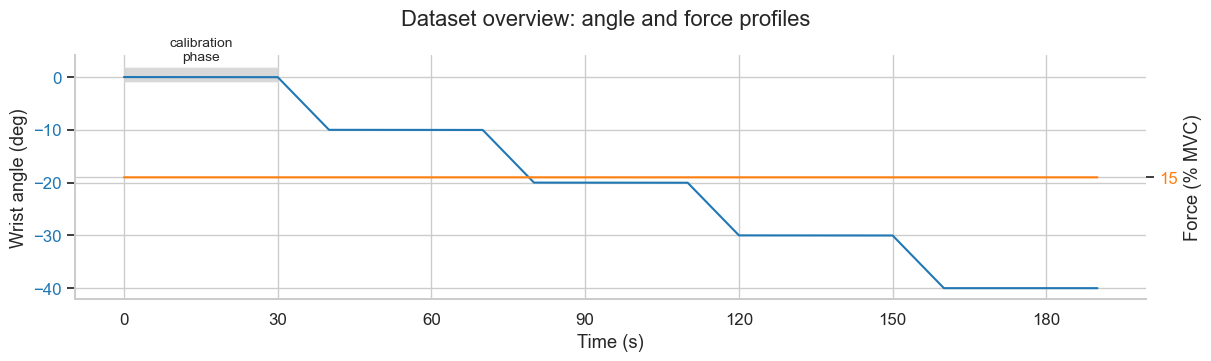

In [4]:
fig, ax = plt.subplots(figsize=(12, 3.5), layout='constrained')
ax.add_patch(Rectangle((0, -1), 30, 3, facecolor='grey', alpha=0.3))
ax.text(15, 5, 'calibration\nphase', dict(ha='center', va='center', fontsize=10))
ax.plot(data['timestamps'], data['angle_profile'], color='tab:blue')
ax.set(ylabel='Wrist angle (deg)', xlabel='Time (s)')
ax.tick_params(axis='y', labelcolor='tab:blue')
ax1 = ax.twinx()
ax1.plot(data['timestamps'], data['force_profile'], color='tab:orange')
ax1.set(ylabel='Force (% MVC)', yticks=[15])
ax1.tick_params(axis='y', labelcolor='tab:orange')
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
    ax1.spines[spine].set_visible(False)
ax1.set(xticks=range(0, int(duration_s) + 1, 30))
plt.suptitle('Dataset overview: angle and force profiles')
plt.show()


## 2. No-adaptation baseline

All adaptation flags off. The calibration V and B are applied unchanged.

In [5]:
_out_no_path = RESULTS_DIR / 'out_no.pt'

if RUN_OPTIMISATION:
    cfg_no = Config()
    cfg_no.ext_fact       = data['ext_fact']
    cfg_no.adapt_wh       = False
    cfg_no.adapt_sv       = False
    cfg_no.adapt_sd       = False
    cfg_no.compute_loss       = True
    cfg_no.device         = 'cpu'
    cfg_no.wh_mode        = 'kl_to_identity'
    cfg_no.contrast_scope = 'spike_based'
    cfg_no.wh_b_coupling  = True

    dec_no = AdaptDecomp(
        emg             = data['emg'].clone(),
        whitening       = data['whitening'].clone(),
        sep_vectors     = data['sep_vectors'].clone(),
        base_centr  = data['base_centr'].clone(),
        spikes_centr = data['spikes_centr'].clone(),
        emg_calib       = data['emg_calib'].clone(),
        ipts_calib      = data['ipts_calib'].clone(),
        spikes_calib    = data['spikes_calib'].clone(),
        preprocess      = data['preprocess'],
        config          = cfg_no,
    )
    out_no = dec_no.run()
    torch.save(out_no, _out_no_path)
    print(f'Saved → {_out_no_path}')
else:
    out_no = torch.load(_out_no_path, weights_only=False)
    print(f'Loaded from {_out_no_path}')
print('No-adaptation run complete.')


Saved → ../data/example/opt_results/kl_to_identity_iterN_coupling/out_no.pt
No-adaptation run complete.


## 3. Single-objective optimisation

Optuna CMA-ES minimises `wh_loss + sv_loss` (`optim_loss='single_obj'`).  centroid_loss is excluded from the objective (0–2% of total, mild anti-signal).  Hyperparameters searched: `max_rel_delta_v`, `max_rel_delta_b`, `centroid_momentum` (see `DEFAULT_PARAM_SPACE`).

In [6]:
# Shared configuration for both optimisation runs
base_config = {
    'ext_fact':       data['ext_fact'],
    'adapt_wh':       True,
    'adapt_sv':       True,
    'adapt_sd':       True,
    'wh_mode':        'kl_to_identity',
    'contrast_scope': 'spike_based',
    'wh_b_coupling':  True,
    'sv_epochs':     5,
    'compute_loss':       True,
    'device':         'cpu',
    'trace_check':    True,
    'optim_loss':     'single_obj',
}

# DEFAULT_PARAM_SPACE: narrowed bounds from root-cause analysis; centroid_momentum
# added as a third parameter to compensate for slow B adaptation in iter1 configs.
# batch_ms is excluded from the default search — use 100 ms (Config default).
# To also search batch_ms: {'batch_ms': ('int', 50, 200), **DEFAULT_PARAM_SPACE}
param_space = DEFAULT_PARAM_SPACE


In [7]:
_cfg_so_path   = RESULTS_DIR / 'best_config_so.json'
_study_so_path = RESULTS_DIR / 'study_so_trials.csv'

if RUN_OPTIMISATION:
    best_config_so, study_so = optimize_adapt_decomp(
        emg             = data['emg'],
        whitening       = data['whitening'],
        sep_vectors     = data['sep_vectors'],
        base_centr  = data['base_centr'],
        spikes_centr = data['spikes_centr'],
        emg_calib       = data['emg_calib'],
        ipts_calib      = data['ipts_calib'],
        spikes_calib    = data['spikes_calib'],
        param_space     = param_space,
        base_config     = base_config,
        n_trials        = 50,
        preprocess      = data['preprocess'],
    )
    with open(_cfg_so_path, 'w') as f:
        json.dump({k: _to_json_safe(v) for k, v in best_config_so.items()}, f, indent=2)
    pd.DataFrame([{'trial': t.number, 'value': t.value, **t.params}
                  for t in study_so.trials if t.value is not None]).to_csv(_study_so_path, index=False)
    print(f'Saved → {_cfg_so_path}')
else:
    with open(_cfg_so_path) as f:
        best_config_so = json.load(f)
    study_so = None
    print(f'Loaded from {_cfg_so_path}')

print('Best hyperparameters (single-obj):')
for k in param_space:
    print(f'  {k}: {best_config_so[k]:.4e}')


Saved → ../data/example/opt_results/kl_to_identity_iterN_coupling/best_config_so.json
Best hyperparameters (single-obj):
  max_rel_delta_v: 1.2421e-03
  max_rel_delta_b: 4.7462e-03
  centroid_momentum: 8.8409e-01


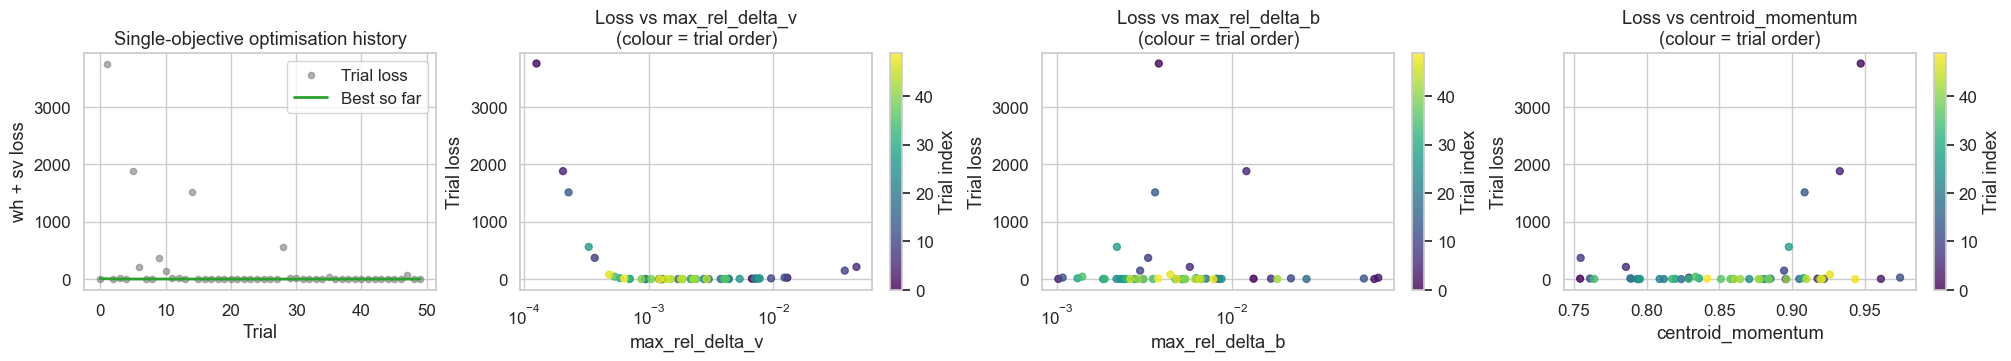

In [8]:
if study_so is None:
    print('Optimisation history not available (loaded from file).')
else:
    values      = [t.value for t in study_so.trials if t.value is not None]
    best_so_far = np.minimum.accumulate(values)

    # Separate log-scale params (delta_v, delta_b) from linear-scale (centroid_momentum)
    log_params    = [k for k, v in param_space.items() if v[0] == 'log_float']
    linear_params = [k for k, v in param_space.items() if v[0] != 'log_float']
    n_panels = 1 + len(log_params) + len(linear_params)
    fig, axs = plt.subplots(1, n_panels, figsize=(5 * n_panels, 3.5), layout='constrained')

    axs[0].scatter(range(len(values)), values, s=20, alpha=0.6, color='tab:grey', label='Trial loss')
    axs[0].plot(range(len(values)), best_so_far, color='tab:green', linewidth=2, label='Best so far')
    axs[0].set(xlabel='Trial', ylabel='wh + sv loss',
               title='Single-objective optimisation history')
    axs[0].legend()

    for ax, name in zip(axs[1:], log_params + linear_params):
        is_log = param_space[name][0] == 'log_float'
        vals = [t.params[name] for t in study_so.trials if name in t.params and t.value is not None]
        cols = [t.value        for t in study_so.trials if name in t.params and t.value is not None]
        sc = ax.scatter(vals, cols, c=range(len(vals)), cmap='viridis', s=25, alpha=0.8)
        if is_log:
            ax.set_xscale('log')
        ax.set(xlabel=name, ylabel='Trial loss',
               title=f'Loss vs {name}\n(colour = trial order)')
        plt.colorbar(sc, ax=ax, label='Trial index')

    plt.show()


Apply the best single-obj config and run the full decomposition.

In [9]:
_out_so_path = RESULTS_DIR / 'out_so.pt'

if RUN_OPTIMISATION:
    cfg_so = Config()
    for k, v in best_config_so.items():
        setattr(cfg_so, k, v)

    dec_so = AdaptDecomp(
        emg             = data['emg'].clone(),
        whitening       = data['whitening'].clone(),
        sep_vectors     = data['sep_vectors'].clone(),
        base_centr  = data['base_centr'].clone(),
        spikes_centr = data['spikes_centr'].clone(),
        emg_calib       = data['emg_calib'].clone(),
        ipts_calib      = data['ipts_calib'].clone(),
        spikes_calib    = data['spikes_calib'].clone(),
        preprocess      = data['preprocess'],
        config          = cfg_so,
    )
    out_so = dec_so.run()
    torch.save(out_so, _out_so_path)
    print(f'Saved → {_out_so_path}')
else:
    out_so = torch.load(_out_so_path, weights_only=False)
    print(f'Loaded from {_out_so_path}')
print('Single-obj adaptation run complete.')


Saved → ../data/example/opt_results/kl_to_identity_iterN_coupling/out_so.pt
Single-obj adaptation run complete.


## 4. Multi-objective optimisation (NSGA-II)

NSGA-II treats wh_loss, sv_loss, and centroid_loss as three independent objectives and returns a Pareto front.  The operating point is the Pareto trial with minimum sum of objectives.

In [10]:
_cfg_mo_path = RESULTS_DIR / 'best_config_mo.json'
_out_mo_path = RESULTS_DIR / 'out_mo.pt'

base_config_mo = {**base_config, 'optim_loss': 'multi_obj'}

if RUN_OPTIMISATION:
    out_mo, best_config_mo, study_mo = run_with_optimization(
        emg             = data['emg'],
        whitening       = data['whitening'],
        sep_vectors     = data['sep_vectors'],
        base_centr  = data['base_centr'],
        spikes_centr = data['spikes_centr'],
        emg_calib       = data['emg_calib'],
        ipts_calib      = data['ipts_calib'],
        spikes_calib    = data['spikes_calib'],
        param_space     = param_space,
        base_config     = base_config_mo,
        n_trials        = 50,
        preprocess      = data['preprocess'],
        optim_mode      = 'multiobjective',
    )
    with open(_cfg_mo_path, 'w') as f:
        json.dump({k: _to_json_safe(v) for k, v in best_config_mo.items()}, f, indent=2)
    torch.save(out_mo, _out_mo_path)
    print(f'Saved → {_cfg_mo_path}, {_out_mo_path}')
    print(f'Pareto front: {len(study_mo.best_trials)} trials')
else:
    with open(_cfg_mo_path) as f:
        best_config_mo = json.load(f)
    out_mo   = torch.load(_out_mo_path, weights_only=False)
    study_mo = None
    print(f'Loaded from {_cfg_mo_path}, {_out_mo_path}')

print('Selected config (multi-objective):')
for k in param_space:
    print(f'  {k}: {best_config_mo[k]:.4e}')


Saved → ../data/example/opt_results/kl_to_identity_iterN_coupling/best_config_mo.json, ../data/example/opt_results/kl_to_identity_iterN_coupling/out_mo.pt
Pareto front: 4 trials
Selected config (multi-objective):
  max_rel_delta_v: 1.9376e-03
  max_rel_delta_b: 8.9108e-03
  centroid_momentum: 8.5153e-01


/opt/miniconda3/envs/adapt_decomp/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/miniconda3/envs/adapt_decomp/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


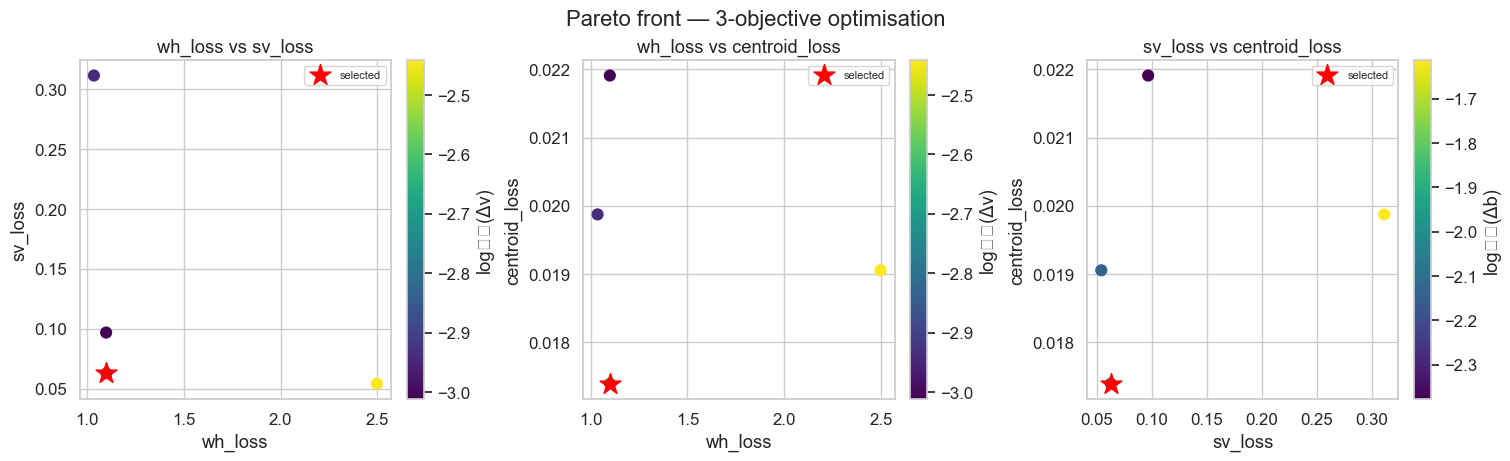

Pareto front: 4 non-dominated trials
Selected: wh=1.1003  sv=0.0629  centroid=0.0174


In [11]:
if study_mo is None:
    print('Pareto front not available (loaded from file).')
else:
    pareto = study_mo.best_trials
    wh_v   = [t.values[0] for t in pareto]
    sv_v   = [t.values[1] for t in pareto]
    ct_v   = [t.values[2] for t in pareto]
    dv_v   = [t.params.get('max_rel_delta_v', float('nan')) for t in pareto]
    db_v   = [t.params.get('max_rel_delta_b', float('nan')) for t in pareto]
    sel    = int(np.argmin([w + s + c for w, s, c in zip(wh_v, sv_v, ct_v)]))

    fig, axs = plt.subplots(1, 3, figsize=(15, 4.5), layout='constrained')
    for ax, (xa, ya, c_vals, clbl, lbl) in zip(axs, [
        (wh_v, sv_v, dv_v, 'log₁₀(Δv)', 'wh_loss vs sv_loss'),
        (wh_v, ct_v, dv_v, 'log₁₀(Δv)', 'wh_loss vs centroid_loss'),
        (sv_v, ct_v, db_v, 'log₁₀(Δb)', 'sv_loss vs centroid_loss'),
    ]):
        sc = ax.scatter(xa, ya, c=np.log10(c_vals), cmap='viridis', s=60, zorder=3)
        ax.scatter(xa[sel], ya[sel], marker='*', s=250, color='red', zorder=4, label='selected')
        plt.colorbar(sc, ax=ax, label=clbl)
        ax.set(xlabel=lbl.split(' vs ')[0], ylabel=lbl.split(' vs ')[1], title=lbl)
        ax.legend(fontsize=8)
    plt.suptitle('Pareto front — 3-objective optimisation')
    plt.show()
    print(f'Pareto front: {len(pareto)} non-dominated trials')
    print(f'Selected: wh={wh_v[sel]:.4f}  sv={sv_v[sel]:.4f}  centroid={ct_v[sel]:.4f}')


## 5. Execution time per batch

In [12]:
cond_labels  = ['No adaptation', 'Single-obj', 'Multi-objective']
cond_colors  = {
    'No adaptation': 'tab:orange',
    'Single-obj':    'tab:blue',
    'Multi-objective': 'tab:green',
}
cond_outputs = {
    'No adaptation': out_no,
    'Single-obj':    out_so,
    'Multi-objective': out_mo,
}


In [13]:
for label in cond_labels:
    out = cond_outputs[label]
    print(label)
    print('-' * len(label))
    for key in ['wh_time_ms', 'sv_time_ms', 'sd_time_ms', 'total_time_ms']:
        print(f'  {key:>15}: {out[key].mean():.3f} ± {out[key].std():.3f} ms')
    print()


No adaptation
-------------
       wh_time_ms: 11.587 ± 3.846 ms
       sv_time_ms: 0.072 ± 0.017 ms
       sd_time_ms: 0.695 ± 0.367 ms
    total_time_ms: 12.354 ± 3.913 ms

Single-obj
----------
       wh_time_ms: 13.867 ± 1.816 ms
       sv_time_ms: 2.691 ± 0.720 ms
       sd_time_ms: 0.520 ± 0.308 ms
    total_time_ms: 17.078 ± 1.992 ms

Multi-objective
---------------
       wh_time_ms: 11.387 ± 1.278 ms
       sv_time_ms: 2.290 ± 0.614 ms
       sd_time_ms: 0.453 ± 0.265 ms
    total_time_ms: 14.129 ± 1.672 ms



## 6. Loss trajectories

- **wh_loss**: KL divergence between online and calibration whitened covariance
- **sv_loss**: squared contrast error per source
- **centroid_loss**: squared centroid deviation per source (logged for monitoring, not included in the single-obj optimisation objective)

Values near zero mean the online statistics match calibration.

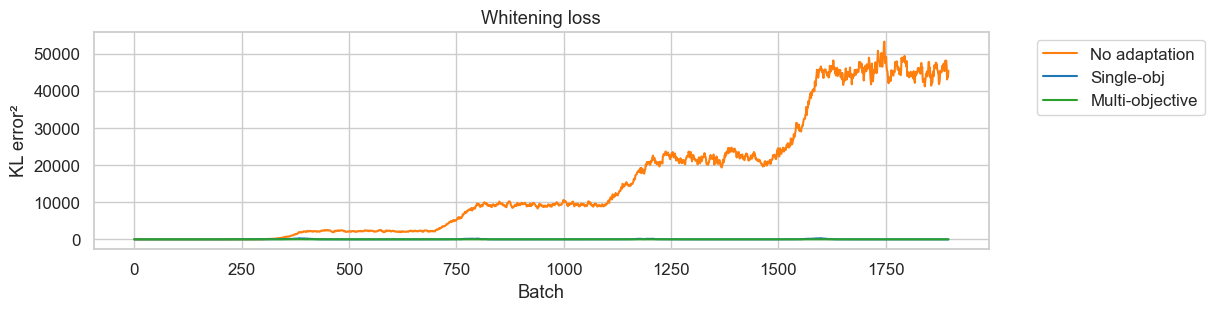

In [14]:
# Whitening loss
fig, ax = plt.subplots(figsize=(12, 3), layout='constrained')
for label in cond_labels:
    ax.plot(cond_outputs[label]['wh_loss'][10:-1], label=label, color=cond_colors[label])
ax.set(xlabel='Batch', ylabel='KL error²', title='Whitening loss')
ax.legend(loc='upper right', bbox_to_anchor=(1.25, 1))
plt.show()


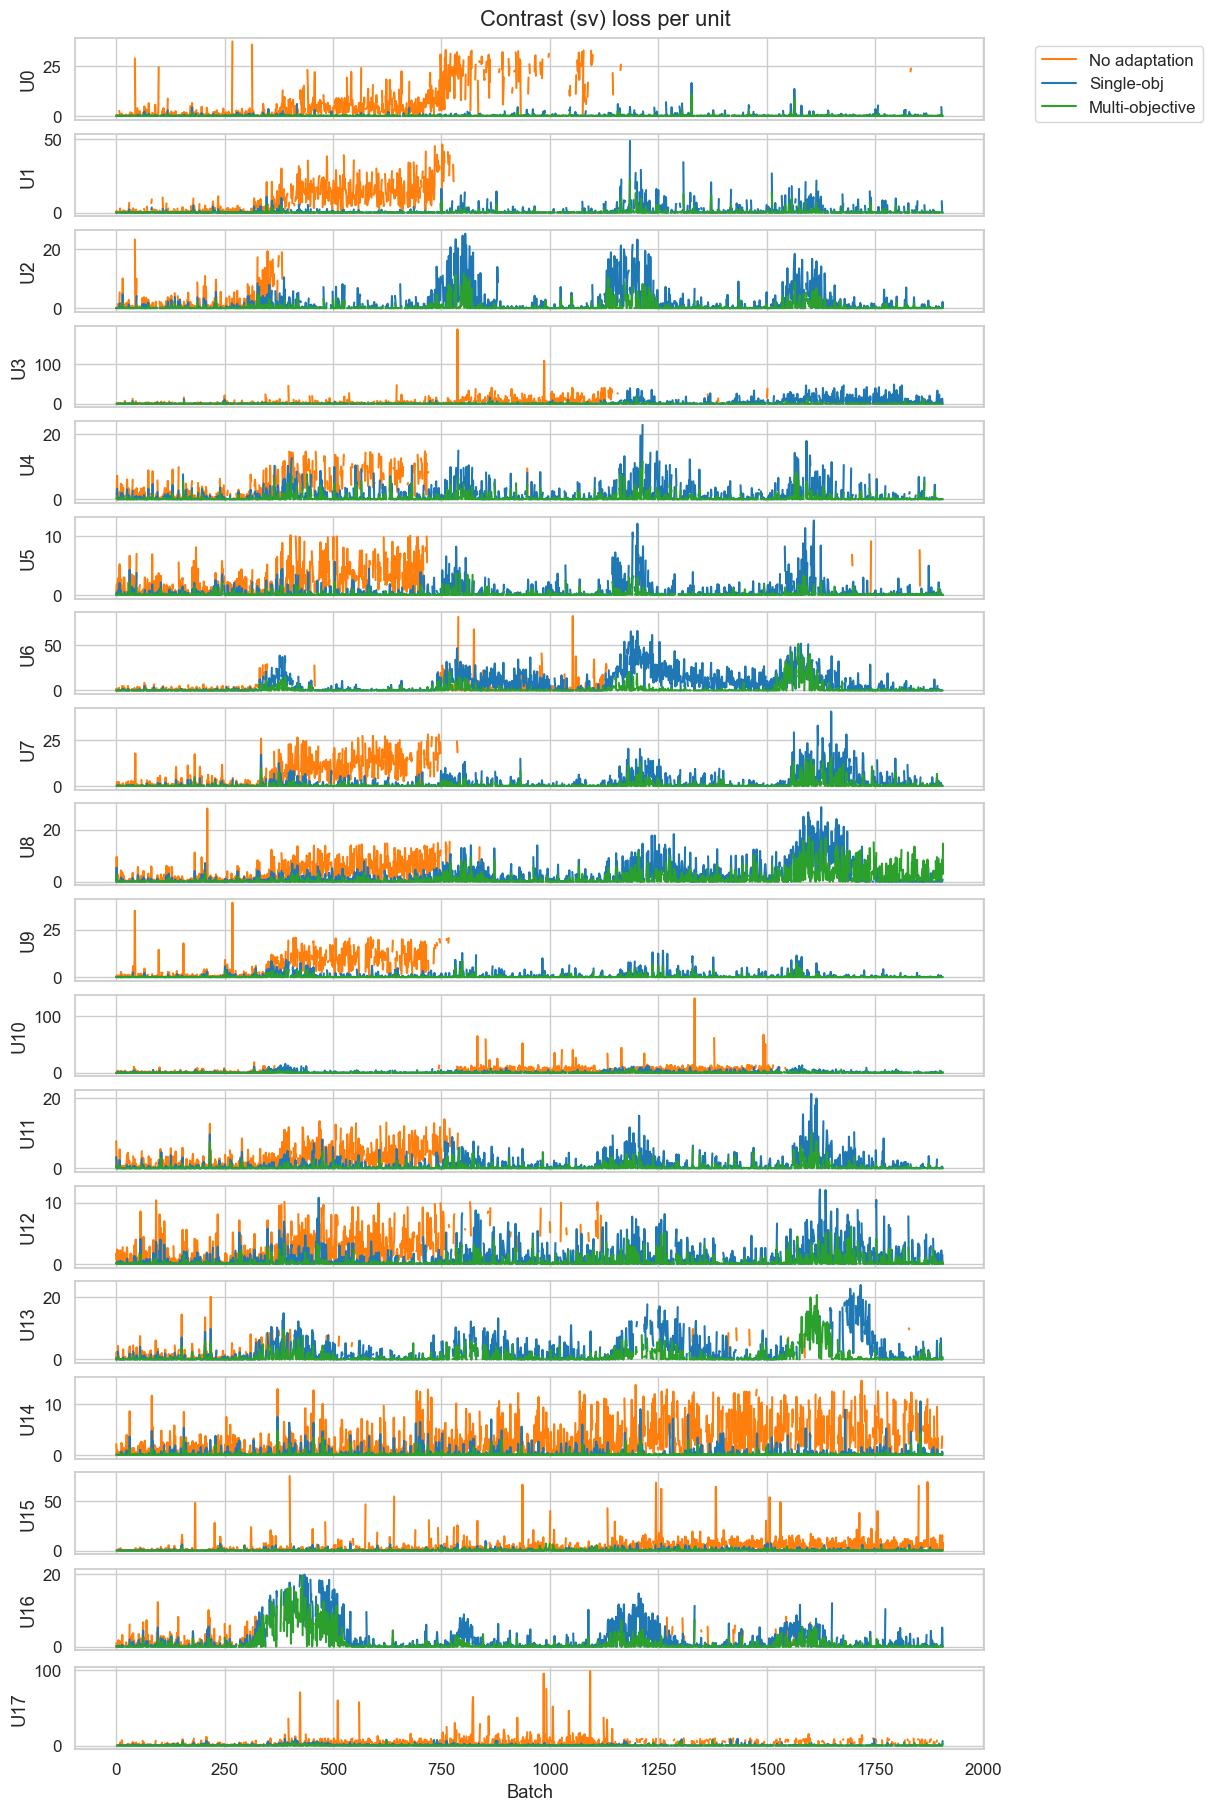

In [15]:
# Contrast (sv) loss per unit
fig, axs = plt.subplots(n_units, 1, figsize=(12, n_units), layout='constrained', sharex=True)
for u in range(n_units):
    for label in cond_labels:
        axs[u].plot(cond_outputs[label]['sv_loss'][:, u], label=label, color=cond_colors[label])
    axs[u].set(ylabel=f'U{u}')
    if u == 0:
        axs[u].legend(loc='upper right', bbox_to_anchor=(1.25, 1))
axs[-1].set(xlabel='Batch')
plt.suptitle('Contrast (sv) loss per unit')
plt.show()


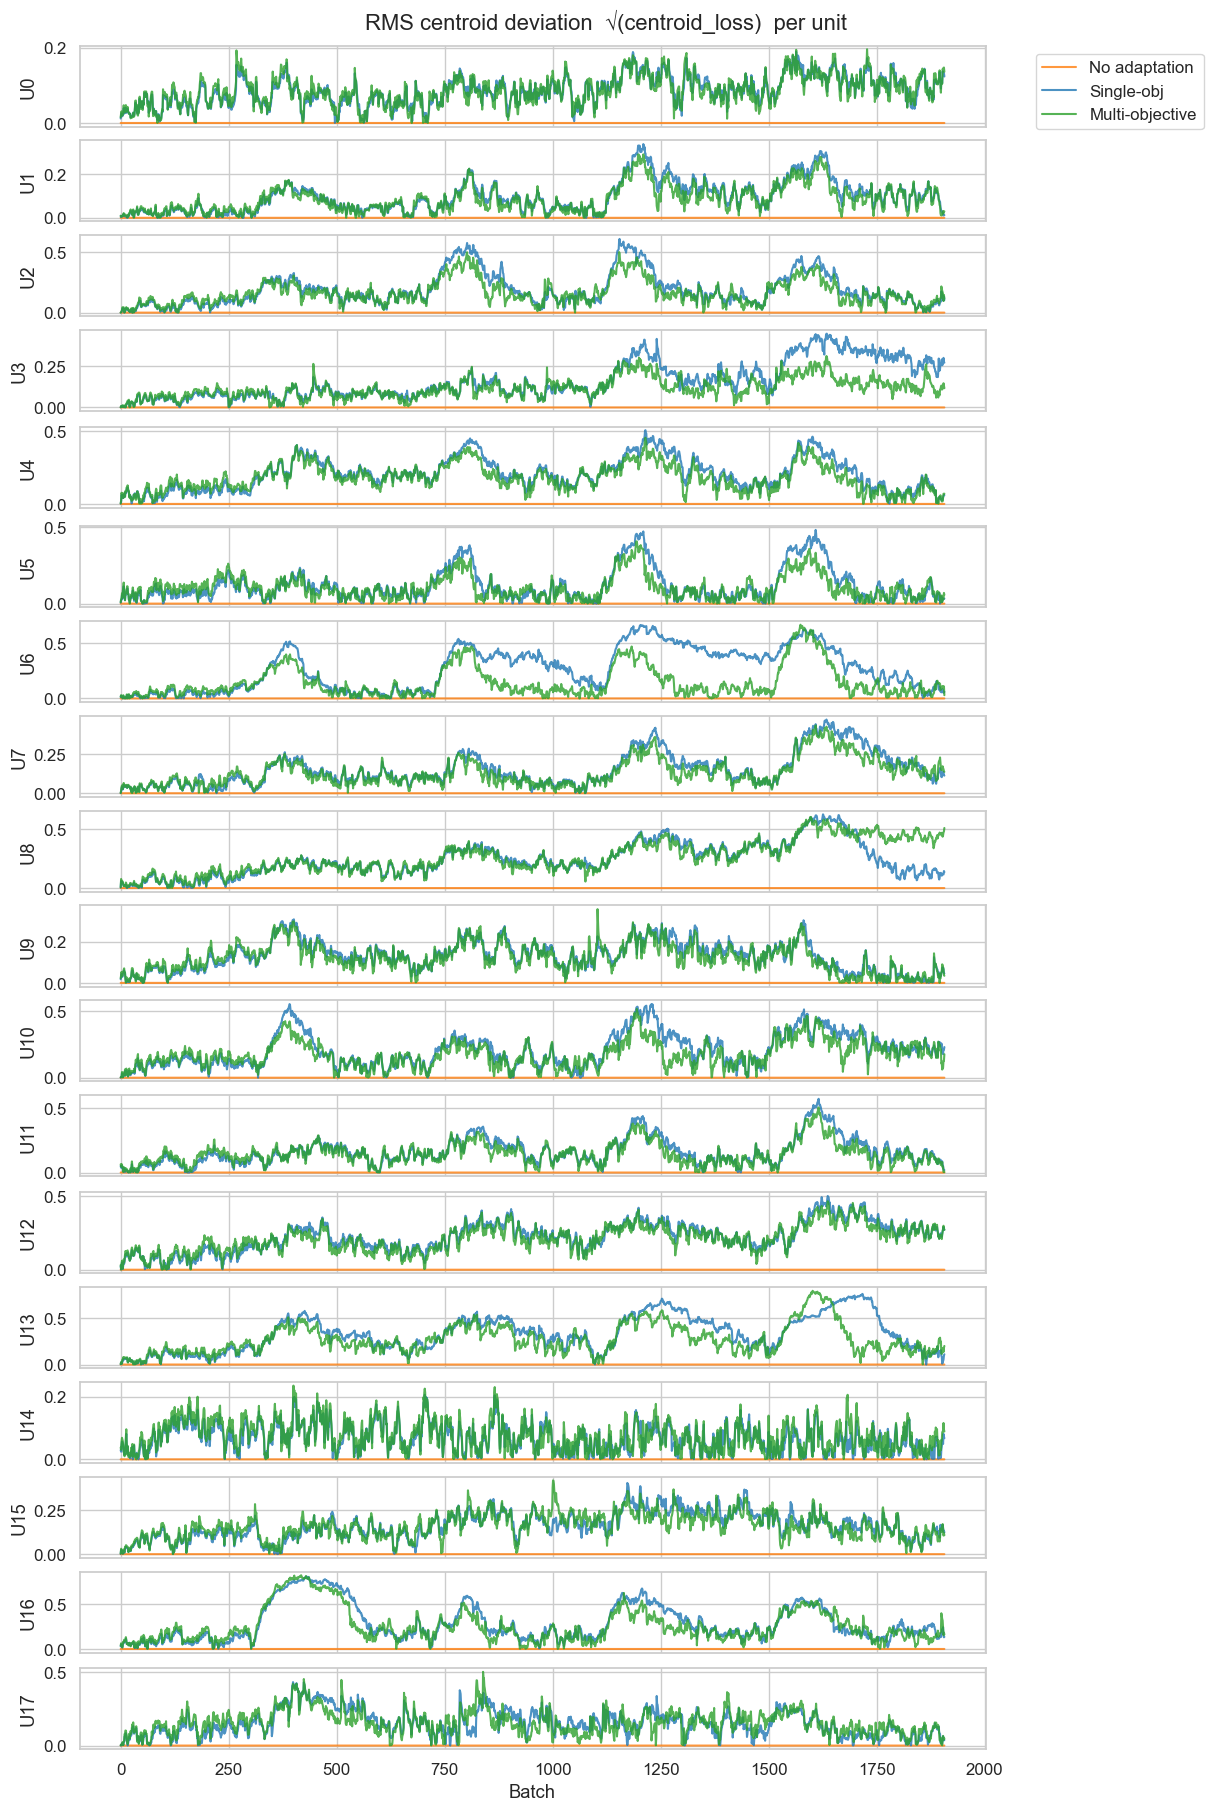

In [16]:
# RMS centroid deviation per unit
fig, axs = plt.subplots(n_units, 1, figsize=(12, n_units), layout='constrained', sharex=True)
for u in range(n_units):
    for label in cond_labels:
        out = cond_outputs[label]
        if 'centroid_loss' in out:
            axs[u].plot(
                np.sqrt(out['centroid_loss'][:, u].numpy()),
                label=label, color=cond_colors[label], alpha=0.8,
            )
    axs[u].set(ylabel=f'U{u}')
    if u == 0:
        axs[u].legend(loc='upper right', bbox_to_anchor=(1.25, 1))
axs[-1].set(xlabel='Batch')
plt.suptitle('RMS centroid deviation  √(centroid_loss)  per unit')
plt.show()


## 7. IPTs and spike trains

Squared IPTs with detected spike times overlaid.

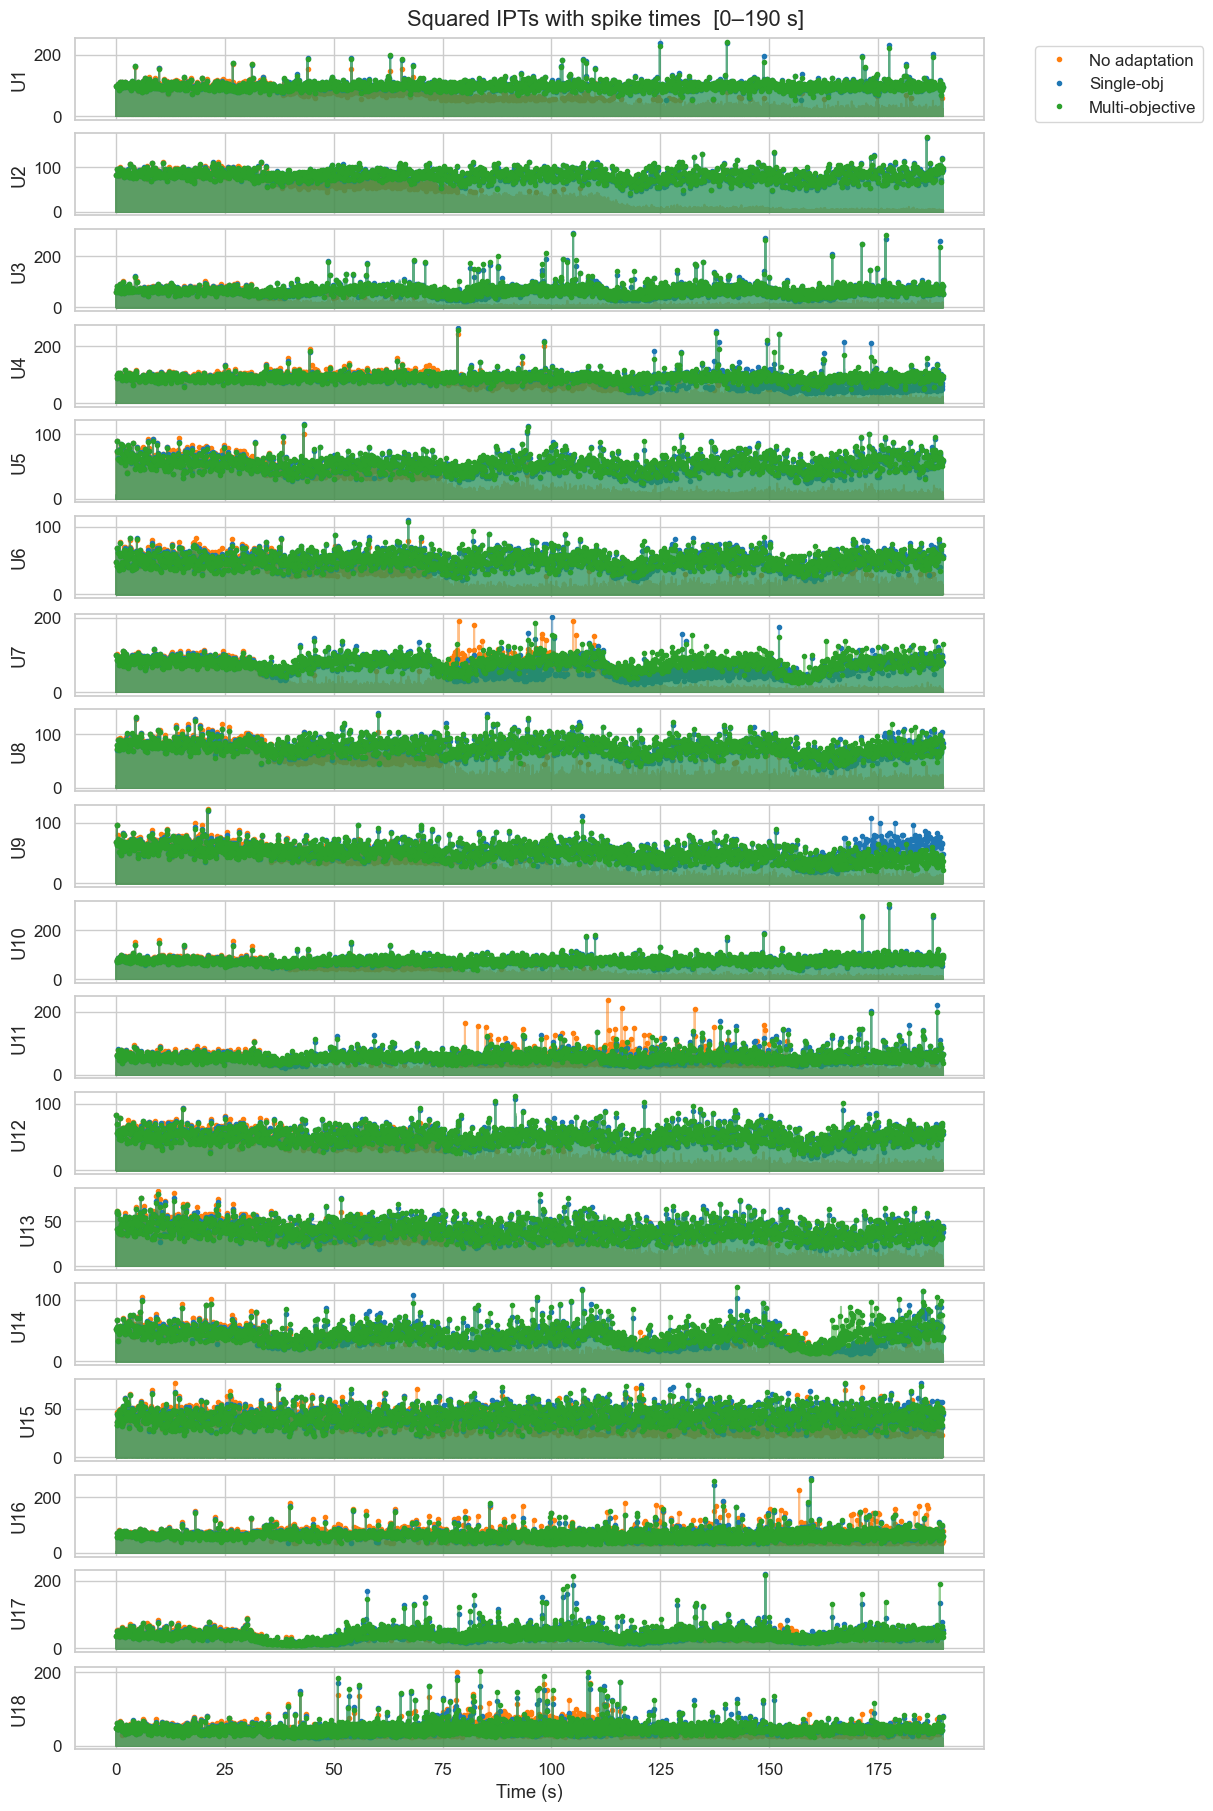

In [17]:
t0, t1 = 0, int(duration_s)
idxs   = np.arange(int(t0 * fs), int(t1 * fs))

fig, axs = plt.subplots(n_units, 1, figsize=(12, n_units), layout='constrained', sharex=True)
for u in range(n_units):
    for label in cond_labels:
        out     = cond_outputs[label]
        ipts_sq = out['ipts'][idxs, u].numpy() ** 2
        axs[u].plot(data['timestamps'][idxs], ipts_sq, color=cond_colors[label], alpha=0.5)
        smask = out['spikes'][idxs, u].to(bool)
        axs[u].plot(
            data['timestamps'][idxs][smask], ipts_sq[smask],
            linestyle='None', marker='.', color=cond_colors[label],
            label=label if u == 0 else None,
        )
    axs[u].set(ylabel=f'U{u + 1}')
axs[0].legend(loc='upper right', bbox_to_anchor=(1.25, 1))
axs[-1].set(xlabel='Time (s)')
plt.suptitle(f'Squared IPTs with spike times  [{t0}–{t1} s]')
plt.show()


## 8. Decomposition quality metrics

A unit is **good** if SIL ≥ 0.9, DR ∈ [5, 35] pps, CoV ≤ 35%, PNR ≥ 30 dB.

In [18]:
rows = []
for label in cond_labels:
    out       = cond_outputs[label]
    spikes_np = out['spikes'].numpy().astype(float)
    ipts_np   = out['ipts'].numpy()

    sil  = get_silhouette_measure(spikes_np, ipts_np, ext_fact)
    pnr  = get_pulse_to_noise_ratio(spikes_np, ipts_np, ext_fact)
    dr   = get_discharge_rate(spikes_np, timestamps, discard_isi=None)
    cov  = get_coefficient_of_variation(spikes_np, timestamps, discard_isi=None)
    good = find_reliable_units(dr, cov, sil, pnr,
                               dr_low_thr=5, dr_upp_thr=35, cov_thr=0.35,
                               sil_thr=0.9, pnr_thr=30)
    for u in range(spikes_np.shape[1]):
        rows.append({'unit': u, 'condition': label, 'good': bool(good[u]),
                     'SIL': sil[u], 'PNR (dB)': pnr[u], 'DR (pps)': dr[u], 'CoV (%)': cov[u]})

df_all  = pd.DataFrame(rows)
n_total = df_all['unit'].nunique()

print(df_all.groupby('condition')[['SIL', 'PNR (dB)', 'DR (pps)', 'CoV (%)']]
      .agg(['median', 'mean']).round(2))
print()
for cond, grp in df_all.groupby('condition'):
    print(f'{cond}: {grp["good"].sum()} / {n_total} good units')


                   SIL       PNR (dB)        DR (pps)        CoV (%)      
                median  mean   median   mean   median   mean  median  mean
condition                                                                 
Multi-objective   0.95  0.94    33.57  34.16     9.83  10.37    0.24  0.32
No adaptation     0.94  0.93    31.78  32.16     5.41   5.91    3.17  3.21
Single-obj        0.94  0.93    33.54  34.04    10.17  10.36    0.30  0.37

Multi-objective: 12 / 18 good units
No adaptation: 0 / 18 good units
Single-obj: 10 / 18 good units


/var/folders/qk/042lzxjj5nzgzp_z1s9jc9dr0000gn/T/ipykernel_88760/3505073099.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_all, x='condition', y=col, order=order, palette=palette,
/var/folders/qk/042lzxjj5nzgzp_z1s9jc9dr0000gn/T/ipykernel_88760/3505073099.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_all, x='condition', y=col, order=order, palette=palette,
/var/folders/qk/042lzxjj5nzgzp_z1s9jc9dr0000gn/T/ipykernel_88760/3505073099.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_all, x='condition', y=

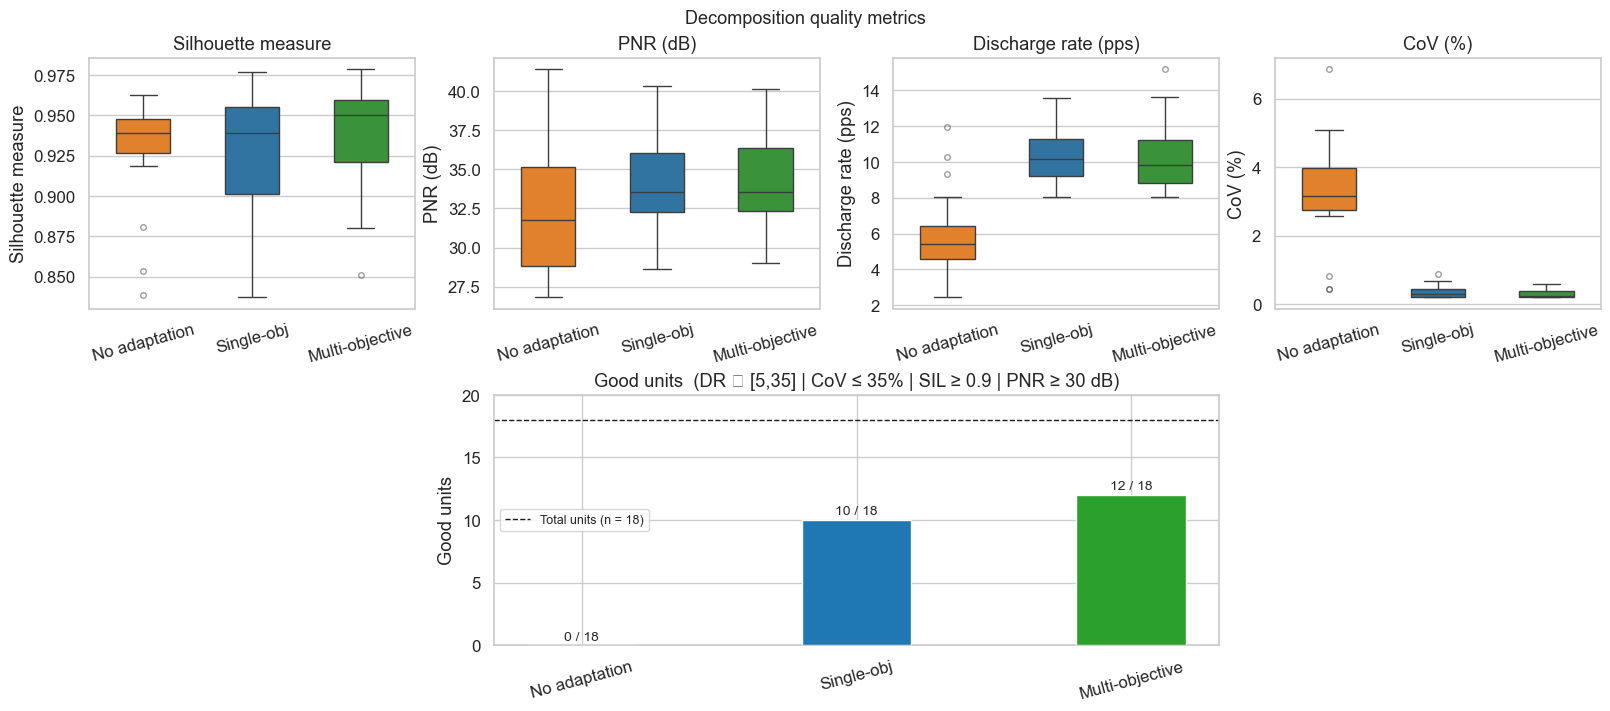

In [19]:
order   = cond_labels
palette = cond_colors

df_all['condition'] = pd.Categorical(df_all['condition'], categories=order, ordered=True)

fig = plt.figure(figsize=(16, 7), layout='constrained')
gs  = fig.add_gridspec(2, 4)
ax_sil = fig.add_subplot(gs[0, 0])
ax_pnr = fig.add_subplot(gs[0, 1])
ax_dr  = fig.add_subplot(gs[0, 2])
ax_cov = fig.add_subplot(gs[0, 3])
ax_bar = fig.add_subplot(gs[1, 1:3])

for ax, col, ylabel in [
    (ax_sil, 'SIL',      'Silhouette measure'),
    (ax_pnr, 'PNR (dB)', 'PNR (dB)'),
    (ax_dr,  'DR (pps)', 'Discharge rate (pps)'),
    (ax_cov, 'CoV (%)',  'CoV (%)'),
]:
    sns.boxplot(data=df_all, x='condition', y=col, order=order, palette=palette,
                width=0.5, flierprops=dict(marker='o', markersize=4, alpha=0.5), ax=ax)
    ax.set(xlabel='', ylabel=ylabel, title=ylabel)
    ax.tick_params(axis='x', rotation=15)

good_counts = df_all.groupby('condition', observed=True)['good'].sum().reindex(order)
bars = ax_bar.bar(order, good_counts.values,
                  color=[palette[c] for c in order], width=0.4, zorder=3)
ax_bar.axhline(n_total, color='k', linestyle='--', linewidth=1,
               label=f'Total units (n = {n_total})')
ax_bar.set(ylabel='Good units', ylim=(0, n_total + 2),
           title='Good units  (DR ∈ [5,35] | CoV ≤ 35% | SIL ≥ 0.9 | PNR ≥ 30 dB)')
ax_bar.legend(fontsize=9)
ax_bar.tick_params(axis='x', rotation=15)
for bar, count in zip(bars, good_counts.values):
    ax_bar.text(bar.get_x() + bar.get_width() / 2, count + 0.2,
                f'{int(count)} / {n_total}', ha='center', va='bottom', fontsize=10)
plt.suptitle('Decomposition quality metrics', fontsize=13)
plt.show()


## 9. Rate of agreement with ground truth

Ground truth spike trains (`spikes_gt`) are available in the simulated dataset.  Unit matching is performed on the calibration segment (first 30 s) using the no-adaptation pairing as the common reference.

In [20]:
cal_idx = np.arange(0, int(30 * fs))

roa_no_cal,  pair_no,  _ = rate_of_agreement(
    data['spikes_gt'].numpy()[cal_idx],
    out_no['spikes'].numpy()[cal_idx],
    fs=fs,
)
roa_so_cal, pair_so, _ = rate_of_agreement(
    data['spikes_gt'].numpy()[cal_idx],
    out_so['spikes'].numpy()[cal_idx],
    fs=fs,
)
roa_mo_cal, pair_mo, _ = rate_of_agreement(
    data['spikes_gt'].numpy()[cal_idx],
    out_mo['spikes'].numpy()[cal_idx],
    fs=fs,
)

print(f'RoA calibration | No adaptation:  {roa_no_cal.mean()*100:.2f} ± {roa_no_cal.std()*100:.2f}%')
print(f'RoA calibration | Single-obj:     {roa_so_cal.mean()*100:.2f} ± {roa_so_cal.std()*100:.2f}%')
print(f'RoA calibration | Multi-obj:      {roa_mo_cal.mean()*100:.2f} ± {roa_mo_cal.std()*100:.2f}%')

# Use no-adapt pairing as common reference
pair_arr   = np.array(pair_no)
sim_spikes = data['spikes_gt'].numpy()[:, pair_arr[:, 0]]


RoA calibration | No adaptation:  99.40 ± 0.49%
RoA calibration | Single-obj:     99.36 ± 0.47%
RoA calibration | Multi-obj:      99.37 ± 0.48%


RoA full | No adaptation:  37.88 ± 18.23%  (med: 37.29%)
RoA full | Single-obj:     77.31 ± 25.77%  (med: 82.66%)
RoA full | Multi-obj:      83.13 ± 25.91%  (med: 97.70%)


/opt/miniconda3/envs/adapt_decomp/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


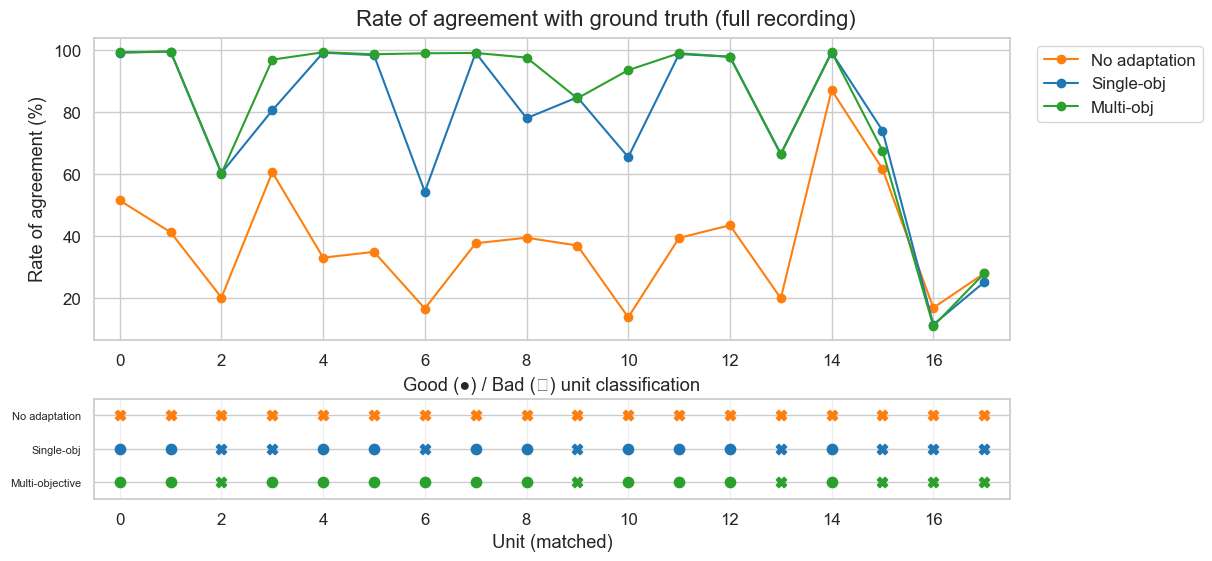

In [21]:
roa_no_full, _, _ = rate_of_agreement_paired(
    sim_spikes, out_no['spikes'].numpy(), fs=fs, tol_spike_ms=2)
roa_so_full, _, _ = rate_of_agreement_paired(
    sim_spikes, out_so['spikes'].numpy(), fs=fs, tol_spike_ms=2)
roa_mo_full, _, _ = rate_of_agreement_paired(
    sim_spikes, out_mo['spikes'].numpy(), fs=fs, tol_spike_ms=2)

unit_ids = pair_arr[:, 1]
n_pairs  = len(unit_ids)
x        = np.arange(n_pairs)

print(f'RoA full | No adaptation:  {roa_no_full.mean()*100:.2f} ± {roa_no_full.std()*100:.2f}%  '
      f'(med: {np.median(roa_no_full)*100:.2f}%)')
print(f'RoA full | Single-obj:     {roa_so_full.mean()*100:.2f} ± {roa_so_full.std()*100:.2f}%  '
      f'(med: {np.median(roa_so_full)*100:.2f}%)')
print(f'RoA full | Multi-obj:      {roa_mo_full.mean()*100:.2f} ± {roa_mo_full.std()*100:.2f}%  '
      f'(med: {np.median(roa_mo_full)*100:.2f}%)')

good_lookup = {
    label: df_all[df_all['condition'] == label].set_index('unit')['good']
    for label in cond_labels
}

fig, (ax_roa, ax_good) = plt.subplots(
    2, 1, figsize=(12, 5.5), layout='constrained',
    gridspec_kw={'height_ratios': [3, 1]},
)
ax_roa.plot(x, roa_no_full * 100, marker='o', label='No adaptation',  color=cond_colors['No adaptation'])
ax_roa.plot(x, roa_so_full * 100, marker='o', label='Single-obj',     color=cond_colors['Single-obj'])
ax_roa.plot(x, roa_mo_full * 100, marker='o', label='Multi-obj',      color=cond_colors['Multi-objective'])
ax_roa.set(ylabel='Rate of agreement (%)', xlim=(-0.5, n_pairs - 0.5))
ax_roa.legend(loc='upper right', bbox_to_anchor=(1.22, 1))

y_pos = {'No adaptation': 2, 'Single-obj': 1, 'Multi-objective': 0}
for label in cond_labels:
    for i, uid in enumerate(unit_ids):
        is_good = bool(good_lookup[label].get(uid, False))
        ax_good.scatter(i, y_pos[label],
                        color=cond_colors[label],
                        marker='o' if is_good else 'X',
                        s=55, zorder=3)

ax_good.set_yticks(list(y_pos.values()))
ax_good.set_yticklabels(list(y_pos.keys()), fontsize=8)
ax_good.set(xlabel='Unit (matched)', xlim=(-0.5, n_pairs - 0.5),
            title='Good (●) / Bad (✗) unit classification',
            ylim=(-0.5, len(y_pos) - 0.5))
ax_good.grid(axis='x', alpha=0.3)
plt.suptitle('Rate of agreement with ground truth (full recording)')
plt.show()


In [22]:
# Save per-unit RoA for the comparison notebook
roa_summary = {
    'unit_ids':    unit_ids.tolist(),
    'roa_no':      roa_no_full.tolist(),
    'roa_so':      roa_so_full.tolist(),
    'roa_mo':      roa_mo_full.tolist(),
}
with open(RESULTS_DIR / 'roa_summary.json', 'w') as f:
    json.dump(roa_summary, f, indent=2)

# Save quality metrics DataFrame
df_all.to_csv(RESULTS_DIR / 'quality_metrics.csv', index=False)
print(f'Saved RoA summary and quality metrics → {RESULTS_DIR}')


Saved RoA summary and quality metrics → ../data/example/opt_results/kl_to_identity_iterN_coupling
